In [1]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import replace_utils4basic_rnn as utils

'''读取数据。目的：准备时序数据，供RNN训练使用'''

#batch_size=32：每次从数据集中读取32个序列样本（每个样本是一个时间步序列）。
#num_steps=35：每个样本包含35个连续的时间步（例如35个字符）。这是RNN每个时间步的输入长度。
batch_size , num_steps = 32 , 35

train_iter,vocab = utils.load_data_time_machine(
    batch_size,num_steps
)

print(vocab)

In [2]:
'''独热编码'''

#torch.tensor([0,2])：创建一个包含两个整数索引的张量，例如对应词汇表中的两个字符。
#F.one_hot(..., len(vocab))：将整数索引转换为one-hot向量。每个索引变成一个长度为len(vocab)的向量，只有对应位置为1，其余为0。
F.one_hot(torch.tensor([0,2]),len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [3]:
X = torch.arange(10).reshape((2,5))
print(F.one_hot(X.T,28).shape)

torch.Size([5, 2, 28])


In [5]:
def get_params(vocab_size,num_hiddens,device):
    #vocab_size：词汇表大小，即输入和输出的特征维度（基于one-hot时的维度）。
    #num_hiddens：隐藏状态的维度（超参数）。
    #device：指定参数存储在CPU还是GPU。

    #num_inputs = num_outputs = vocab_size：输入层和输出层的特征数都等于词汇表大小（因为每一步输入和输出都是one-hot向量或logits）。
    num_inputs = num_outputs = vocab_size
    #目的：定义RNN模型参数生成函数

    #辅助函数：生成指定形状的标准正态分布随机张量，并乘以0.01，使权重初始值很小（避免初始梯度饱和）。
    def normal(shape):
        return torch.randn(size=shape,device=device) * 0.01
    #输入到隐藏状态的权重矩阵，用于计算x_t * W_xh
    W_xh = normal((num_inputs,num_hiddens))
    #上一时刻隐藏状态到当前隐藏状态的权重矩阵，用于计算h_{t-1} * W_hh
    W_hh = normal((num_hiddens,num_hiddens))
    #隐藏状态的偏置
    b_h = torch.zeros(num_hiddens,device=device)
    #这些是RNN核心参数，对应公式：h_t = tanh(x_t W_xh + h_{t-1} W_hh + b_h)

    #隐藏状态到输出层的权重矩阵
    W_hq = normal((num_hiddens,num_outputs))
    #输出层的偏置
    b_q = torch.zeros(num_outputs,device=device)
    #对应公式：o_t = h_t W_hq + b_q（输出logits，后续用于softmax得到概率）

    #将所有参数放入列表，并设置requires_grad=True，表示需要计算梯度（以便自动反向传播）
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [6]:
#一个init_rnn_state函数在初始化时返回隐藏状态
def init_rnn_state(batch_size,num_hiddens,device):
    return (torch.zeros((batch_size,num_hiddens),device=device),)

In [7]:
#定义如何在一个时间步内计算隐藏状态和输出
def rnn(inputs,state,params):
    W_xh,W_hh,b_h,W_hq,b_q = params
    #解包元组，取出隐藏状态
    H, = state
    outputs = []
    #遍历每个时间步
    for X in inputs:
        #更新隐藏状态
        H = torch.tanh(torch.mm(X,W_xh) + torch.mm(H,W_hh) + b_h)
        #计算输出
        Y = torch.mm(H,W_hq) + b_q
        outputs.append(Y)
    #返回所有时间步的输出和最终隐藏状态
    return torch.cat(outputs,dim=0),(H,)

In [8]:
#创建一个类来包装这些函数
class RNNModelScratch:
    '''从零开始实现的循环神经网络模型'''
    #vocab_size: 词汇表大小（即 one-hot 向量长度，也是输出维度）
    #num_hiddens: 隐藏状态维度
    #device: 计算设备（CPU 或 GPU）
    #get_params: 之前定义的参数初始化函数，返回 (W_xh, W_hh, b_h, W_hq, b_q)
    #init_state: 初始化隐藏状态的函数（如 init_rnn_state）
    #forward_fn: RNN 的前向计算函数（如 rnn）

    #将RNN所需的所有组件（参数、状态初始化、前向计算）封装在一起
    def __init__(self,vocab_size,num_hiddens,device,get_params,init_state,forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size,num_hiddens,device)
        self.init_state, self.forward_fn = init_state,forward_fn

    #使实例可调用
    def __call__(self,X,state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    #初始化隐藏状态
    def begin_state(self,batch_size,device):
        return self.init_state(batch_size, self.num_hiddens, device)

In [9]:
#检查输出是否具有正确的形状
num_hiddens = 512
net = RNNModelScratch(len(vocab),num_hiddens,d2l.try_gpu(),get_params,init_rnn_state,rnn)
state = net.begin_state(X.shape[0],d2l.try_gpu())
Y, new_state = net(X.to(d2l.try_gpu()),state)
print(Y.shape, len(new_state), new_state[0].shape)

torch.Size([10, 44]) 1 torch.Size([2, 512])


In [10]:
#定义预测函数来生成prefix之后的新字符
def predict_ch8(prefix,num_preds,net,vocab,device):
    '''在prefix后面生成新字符'''
    #prefix: 初始字符串，模型根据它来预测后续字符。
    #num_preds: 要生成的新字符个数。
    #net: 训练好的 RNN 模型（例如 RNNModel 实例）。
    #vocab: 词汇表对象，支持 vocab[char] 获取字符索引，以及 vocab.idx_to_token 将索引转回字符

    #初始化隐藏状态。batch_size=1表示依次只生成一个样本
    state = net.begin_state(batch_size=1,device=device)
    #outputs列表用于存储已经生成的所有字符的索引
    outputs = [vocab[prefix[0]]]
    #返回一个形状为(1,1)的张量，内容为outputs最后一个字符的索引，此张量作为RNN模型每一步的输入
    get_input = lambda:torch.tensor([outputs[-1]],device=device).reshape((1,1))
    #遍历prefix除第一个字符之外的其余字符
    for y in prefix[1:]:
        #前向传播得到输出和新的隐藏状态，此处不使用预测值而下一步使用真实值（teacher forcing）
        _, state = net(get_input(), state)
        #将真实值的索引加入outputs列表
        outputs.append(vocab[y])
    #循环num_preds次，生成新字符
    for _ in range(num_preds):
        #得到预测输出y和新的隐藏状态state
        y, state = net(get_input(), state)
        #取概率最高的类别的索引
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    #将存储的索引转换为字符并用空字符串连接成最终结果
    return ''.join([vocab.idx_to_token[i] for i in outputs])

print(predict_ch8('time travelller',10,net,vocab,d2l.try_gpu()))

time travelller-d8qbg?okt


In [11]:
#梯度裁剪
def grad_clipping(net,theta):
    '''裁剪梯度'''
    #判断net是否为nn.Module的实例
    if isinstance(net,nn.Module):
        #如果是,则获取所有需要计算梯度的参数
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        #否则，假设net是一个自定义对象，其参数存在net.params中
        params = net.params
    #计算所有参数梯度的L2范数
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    #范数超过阈值theta
    if norm > theta:
        #执行梯度裁剪（梯度乘以(theta/norm)）
        #param.grad[:]表示原地修改梯度值
        for param in params:
            param.grad[:] *= theta/ norm

In [12]:
#定义一个函数在一个迭代周期内训练模型
def train_epoch_ch8(net, train_iter, loss, updater, device,use_random_iter):
    '''训练模型一个迭代周期'''
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)
    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0],device=device)
        else:
            if isinstance(net,nn.Module) and not isinstance(state,tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat,y.long()).mean()
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net,1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net,1)
            updater(batch_size=1)
        metric.add(l*y.numel(), y.numel())
    return math.exp(metric[0]/metric[1]), metric[1]/timer.stop()

In [13]:
#高级API实现RNN的训练函数
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch',ylabel='perplexity',
                            legend=['train'],xlim=[10,num_epochs])
    if isinstance(net,nn.Module):
        updater = torch.optim.SGD(net.parameters(),lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params,lr,batch_size)
    predict = lambda prefix: predict_ch8(prefix,50,net,vocab,device)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )
        if (epoch+1)%10 == 0:
            print(predict('timer traveller'))
            animator.add(epoch+1,[ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} tokens/sec {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

困惑度 20.5, 116251.3 tokens/sec cuda:0
time traveller, han on  an th  an th  an th  an th  an th  an th
travellerhan the th  an th  an th  an th  an th  an th  an 


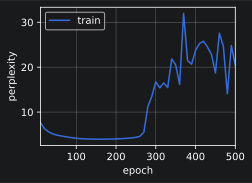

In [14]:
#开始训练
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

困惑度 17.8, 112366.1 tokens/sec cuda:0
time traveller the the to the the the to the the the to the the 
travellert the the the to the the the to the the the to the


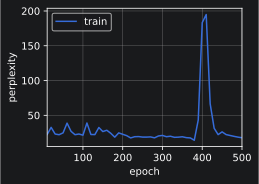

In [15]:
#检查一下使用随机抽样方法的结果
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(), use_random_iter=True)